# Equations of motion by differentiation: an n-link pendulum from its Lagrangian

This notebook derives the equations of motion of a planar chain of pendulums **without writing them
down**. The only modelling is the positions of the masses; everything else — the mass matrix, the
velocity-product (Coriolis and centrifugal) terms, the generalized forces — is obtained by
differentiating a Lagrangian with Scaly, and the result is compiled to C.

Along the way it shows:

| Scaly feature | Where |
| --- | --- |
| derivatives with respect to *expressions* (`sc.gradient`, `sc.jacobian`, `sc.hessian` of a graph in its own intermediate values) | the Euler–Lagrange equations |
| dense linear algebra as generated code (`linalg.cholesky`, `linalg.cho_solve`) | the forward dynamics $\ddot q = M^{-1}(\cdot)$ |
| `sc.scan` | an RK4 integrator over thousands of steps, as one C loop |
| forward-mode Jacobians through a scan | the sensitivity of the final state to the initial one, and a Lyapunov exponent |
| `write_module` | the forward dynamics as a standalone C file |

The script version is `examples/lagrangian_mechanics.py`.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "lagrangian_mechanics"
G = 9.81

## The model: positions only

Take $n$ point masses $m_k$ on massless rods of lengths $\ell_k$, with absolute angles $q_k$
measured from the downward vertical. Mass $k$ sits at

$$
x_k = \sum_{j \le k} \ell_j \sin q_j, \qquad y_k = -\sum_{j \le k} \ell_j \cos q_j .
$$

Its velocity is $\dot p_k = \frac{\partial p_k}{\partial q}\,\dot q$, so the kinetic and potential
energies and the Lagrangian are

$$
T = \tfrac12 \sum_k m_k \lVert \dot p_k \rVert^2, \qquad V = g \sum_k m_k y_k, \qquad L(q, \dot q) = T - V .
$$

In code, `sc.jacobian(x, q)` differentiates the position expression with respect to the angle
expression `q` inside the same graph; nothing needs to be a separate `Function` for that.

In [2]:
def make_lagrangian(masses, lengths):
  n = len(masses)
  lower = np.tril(np.ones((n, n))) * lengths  # row k sums the rods up to k

  def lagrangian(q, qd):
    x, y = sc.const(lower) @ q.sin(), -(sc.const(lower) @ q.cos())
    vx, vy = sc.jacobian(x, q) @ qd, sc.jacobian(y, q) @ qd
    kinetic = 0.5 * (sc.const(masses) * (vx * vx + vy * vy)).sum()
    potential = G * (sc.const(masses) * y).sum()
    return kinetic - potential, kinetic + potential  # L and the total energy

  return lagrangian

## Euler–Lagrange by AD

With the generalized momenta $p = \partial L / \partial \dot q$, the Euler–Lagrange equations
$\frac{d}{dt} p = \partial L / \partial q + \tau$ expand to

$$
\underbrace{\frac{\partial^2 L}{\partial \dot q^2}}_{M(q)} \ddot q
\;+\; \frac{\partial^2 L}{\partial \dot q\, \partial q}\, \dot q \;-\; \frac{\partial L}{\partial q} \;=\; \tau ,
$$

so the forward dynamics is one symmetric positive-definite solve,
$\ddot q = M(q)^{-1}\big(\tau + \partial L/\partial q - (\partial p/\partial q)\,\dot q\big)$.
Each term is one Scaly derivative; the solve is the generated dense Cholesky. `forward_dynamics`
is a typed `Function`: it can be called with arrays (it compiles on first call) or with
expressions (it becomes a call node in a larger graph, as in the integrator below).

In [3]:
def make_forward_dynamics(masses, lengths):
  n = len(masses)
  lagrangian = make_lagrangian(masses, lengths)

  @sc.function(sc.G(sc.L("q", n), sc.L("qd", n), sc.L("tau", n)), sc.G(sc.L("qdd", n), sc.L("M", (n, n))))
  def forward_dynamics(inputs):
    q, qd, tau = inputs
    lag, _ = lagrangian(q, qd)
    p = sc.gradient(lag, qd)  # generalized momenta
    mass = sc.jacobian(p, qd)  # M(q) = d^2 L / dqd^2
    rhs = tau + sc.gradient(lag, q) - sc.jacobian(p, q) @ qd
    return linalg.cho_solve(linalg.cholesky(mass), rhs), mass

  @sc.function(sc.G(sc.L("q", n), sc.L("qd", n)), sc.L("E", ()))
  def energy(inputs):
    return lagrangian(*inputs)[1]

  return forward_dynamics, energy

### Check: the double pendulum

For two links the equations are in every textbook. The accelerations derived above agree with the
closed form to rounding error, and the mass matrix is the familiar
$\begin{pmatrix} (m_1+m_2)\ell_1^2 & m_2 \ell_1 \ell_2 \cos(q_1-q_2) \\ \cdot & m_2 \ell_2^2 \end{pmatrix}$.

In [4]:
def double_pendulum_textbook(q, qd, m, lengths):
  (t1, t2), (w1, w2), (m1, m2), (l1, l2) = q, qd, m, lengths
  d = t1 - t2
  den = 2 * m1 + m2 - m2 * np.cos(2 * d)
  a1 = (-G * (2 * m1 + m2) * np.sin(t1) - m2 * G * np.sin(t1 - 2 * t2) - 2 * np.sin(d) * m2 * (w2**2 * l2 + w1**2 * l1 * np.cos(d))) / (l1 * den)
  a2 = (2 * np.sin(d) * (w1**2 * l1 * (m1 + m2) + G * (m1 + m2) * np.cos(t1) + w2**2 * l2 * m2 * np.cos(d))) / (l2 * den)
  return np.array([a1, a2])


m2, l2 = np.array([1.0, 0.5]), np.array([1.0, 0.7])
fd2, _ = make_forward_dynamics(m2, l2)
q, qd = np.array([0.9, -1.3]), np.array([0.4, -0.2])
qdd, mass = fd2((q, qd, np.zeros(2)))
print("qdd from the Lagrangian:", qdd)
print("qdd from the textbook:  ", double_pendulum_textbook(q, qd, m2, l2))
print("M(q) =\n", mass)
print("expected M12 =", m2[1] * l2[0] * l2[1] * np.cos(q[0] - q[1]))

qdd from the Lagrangian: [-6.57091269  8.16410823]
qdd from the textbook:   [-6.57091269  8.16410823]
M(q) =
 [[ 1.5        -0.20597539]
 [-0.20597539  0.245     ]]
expected M12 = -0.20597539103937101


## Simulating a triple pendulum with an RK4 `scan`

Classical RK4 with a fixed step $h$ is a function from one state $x = (q, \dot q)$ to the next.
`sc.scan` applies it `STEPS` times; its body's first output is the next state (the *carry*) and the
other outputs are stacked, one row per step: here the energy and the state itself, for plotting.
In C this is a single loop whose body calls the forward dynamics four times; the source size does
not depend on the number of steps.

In [5]:
DT, STEPS = 1e-3, 5000
masses3, lengths3 = np.ones(3), np.ones(3)
fd3, energy3 = make_forward_dynamics(masses3, lengths3)
n = 3
zero = sc.const(np.zeros(n))


def f(x):
  return sc.concat([x[n:], fd3((x[:n], x[n:], zero))[0]])


@sc.function(sc.L("x", 2 * n), sc.G(sc.L("x_next", 2 * n), sc.L("E", 1), sc.L("x_log", 2 * n)))
def rk4_step(x):
  k1 = f(x)
  k2 = f(x + 0.5 * DT * k1)
  k3 = f(x + 0.5 * DT * k2)
  k4 = f(x + DT * k3)
  return x + DT / 6 * (k1 + 2 * k2 + 2 * k3 + k4), energy3((x[:n], x[n:])).reshape((1,)), x


@sc.function(
  sc.L("x0", 2 * n),
  sc.G(sc.L("x_final", 2 * n), sc.L("energies", STEPS), sc.L("trajectory", STEPS * 2 * n), sc.L("sensitivity", (2 * n, 2 * n))),
)
def simulate(x0):
  x_final, energies, trajectory = sc.scan(rk4_step, x0, [], length=STEPS)
  return x_final, energies, trajectory, sc.jacobian(x_final, x0)


x0 = np.array([2.0, 2.2, 2.4, 0.0, 0.0, 0.0])
simulate(x0)  # the first call generates and compiles
start = time.perf_counter()
x_final, energies, trajectory, sensitivity = simulate(x0)
print(f"{STEPS} RK4 steps and the 6 x 6 sensitivity through them: {1e3 * (time.perf_counter() - start):.1f} ms")
trajectory = trajectory.reshape(STEPS, 2 * n)

5000 RK4 steps and the 6 x 6 sensitivity through them: 7.3 ms


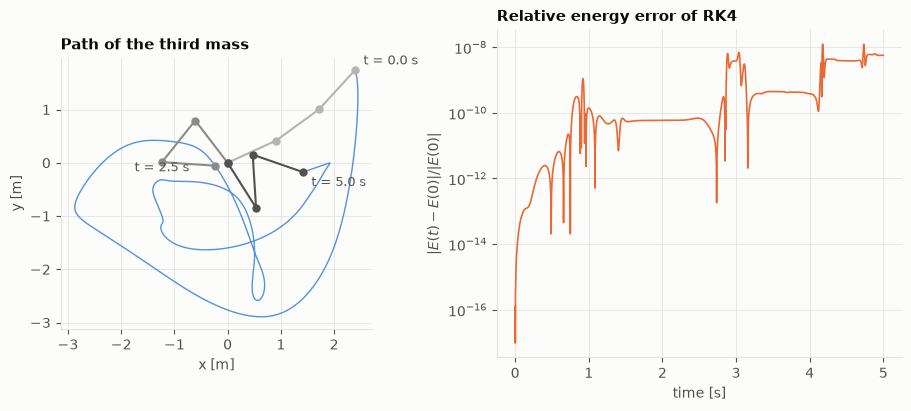

In [6]:
t = DT * np.arange(STEPS)
angles = trajectory[:, :n]
xs = np.cumsum(np.sin(angles) * lengths3, axis=1)
ys = -np.cumsum(np.cos(angles) * lengths3, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 1.3]})
ax1.plot(xs[:, 2], ys[:, 2], lw=1.0, color=plotstyle.BLUE, alpha=0.8)
for k, shade, offset in ((0, "#b5b4ae", (6, 4)), (STEPS // 2, "#8c8b86", (-58, -4)), (STEPS - 1, "#52514e", (6, -10))):
  ax1.plot(np.r_[0, xs[k]], np.r_[0, ys[k]], "-o", color=shade, lw=1.5, ms=5, zorder=3)
  ax1.annotate(f"t = {t[k]:.1f} s", (xs[k, 2], ys[k, 2]), xytext=offset, textcoords="offset points", color=plotstyle.TEXT_SECONDARY, fontsize=9)
ax1.set_aspect("equal")
ax1.set_title("Path of the third mass")
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")

ax2.semilogy(t, np.abs(energies - energies[0]) / abs(energies[0]) + 1e-17, color=plotstyle.ORANGE, lw=1.2)
ax2.set_title("Relative energy error of RK4")
ax2.set_xlabel("time [s]")
ax2.set_ylabel(r"$|E(t) - E(0)| / |E(0)|$")
plt.show()

Energy is conserved to about $10^{-8}$ over the run, which checks the derivation more stringently than
any single evaluation could: an error in any term of the equations of motion would show up as a
secular drift.

## Chaos: a Lyapunov exponent from the Jacobian through the scan

`sensitivity` $= \partial x(T) / \partial x(0)$ was computed in the same call, by forward mode
through the scan (six tangents carried alongside the state in the same loop). Its largest singular
value $\sigma_1$ gives the finite-time Lyapunov exponent $\lambda_T = \log(\sigma_1)/T$: nearby
trajectories separate like $e^{\lambda_T t}$ along the leading right singular vector $v_1$.

We check this against brute force: simulate a second pendulum started $10^{-9}$ away along $v_1$
and watch the two separate.

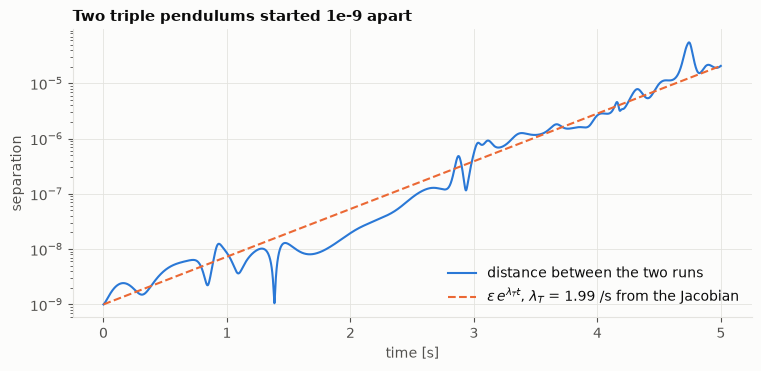

separation at T: 2.062e-05, predicted 2.071e-05


In [7]:
_, s, vt = np.linalg.svd(sensitivity)
t_final = STEPS * DT
ftle = np.log(s[0]) / t_final
eps = 1e-9
_, _, twin, _ = simulate(x0 + eps * vt[0])
separation = np.linalg.norm(twin.reshape(STEPS, 2 * n) - trajectory, axis=1)

fig, ax = plt.subplots()
ax.semilogy(t, separation, color=plotstyle.BLUE, lw=1.5, label="distance between the two runs")
ax.semilogy(t, eps * np.exp(ftle * t), "--", color=plotstyle.ORANGE, lw=1.5, label=rf"$\epsilon\, e^{{\lambda_T t}}$, $\lambda_T$ = {ftle:.2f} /s from the Jacobian")
ax.set_xlabel("time [s]")
ax.set_ylabel("separation")
ax.set_title("Two triple pendulums started 1e-9 apart")
ax.legend(loc="lower right")
plt.show()
print(f"separation at T: {separation[-1]:.3e}, predicted {eps * s[0]:.3e}")

The separation follows the prediction on average (a finite-time exponent says nothing about the path
in between, which wiggles as the stretching direction rotates) and lands on
$\epsilon\,\sigma_1$ at the final time.

## The generated C

`write_module` renders the same translation unit the JIT compiled. The forward dynamics is a
self-contained C function with the pointer ABI (`arg`, `res`, `iw`, `w`) and, in the header, one
struct per buffer; the only dependency is `libm`.

In [8]:
module = write_module(fd3, GENERATED)
write_module(simulate, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, workspace {module.workspace_size} doubles")
print("\n".join(line for line in module.header.splitlines() if "typedef" in line or "static inline" in line))

forward_dynamics.c: 697 lines, workspace 0 doubles
typedef struct { SCALY_ALIGNAS(16) double data[3]; } forward_dynamics_q_t;
typedef struct { SCALY_ALIGNAS(16) double data[3]; } forward_dynamics_qd_t;
typedef struct { SCALY_ALIGNAS(16) double data[3]; } forward_dynamics_tau_t;
typedef struct { SCALY_ALIGNAS(16) double data[3]; } forward_dynamics_qdd_t;
typedef struct { SCALY_ALIGNAS(16) double data[9]; } forward_dynamics_M_t;
typedef struct { SCALY_ALIGNAS(16) double data[forward_dynamics_SZ_W > 0 ? forward_dynamics_SZ_W : 1]; } forward_dynamics_workspace_t;
static inline int forward_dynamics_call(const forward_dynamics_q_t* q, const forward_dynamics_qd_t* qd, const forward_dynamics_tau_t* tau, forward_dynamics_qdd_t* qdd, forward_dynamics_M_t* M, forward_dynamics_workspace_t* workspace) {
